# Fashion MNIST Classification using CNN

This project uses a Convolutional Neural Network (CNN) to classify Fashion MNIST images into 10 clothing categories.

## Objective

The objective is to build a deep learning model that can classify grayscale fashion images such as shirts, shoes, bags, trousers, and other clothing items.

## Dataset Description

Fashion MNIST contains 70,000 grayscale images of fashion products.

- 60,000 training images
- 10,000 test images
- Image size: 28 × 28 pixels
- Number of classes: 10

In [1]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

## Data Loading

In [2]:
# load and prepare the Fashion MNIST dataset
fashion_mnist = datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels) = fashion_mnist.load_data()

## Data Preprocessing

In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [4]:
type(train_images)

numpy.ndarray

In [5]:
type(train_labels)

numpy.ndarray

In [28]:
print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Training images: (60000, 28, 28, 1)
Training labels: (60000,)
Test images: (10000, 28, 28, 1)
Test labels: (10000,)


In [7]:
print(train_images[0].shape)

(28, 28)


In [8]:
print("Image shape:", train_images[0].shape)
print("Pixel value range:", train_images[0].min(), "to", train_images[0].max())

Image shape: (28, 28)
Pixel value range: 0 to 255


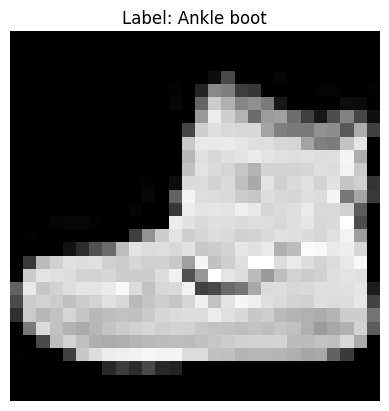

In [27]:
# display an image from the dataset
plt.imshow(train_images[0],cmap="gray")
plt.title(f"Label: {class_names[train_labels[0]]}")
plt.axis("off")
plt.show()

In [10]:
import cv2
from google.colab.patches import cv2_imshow

cv2_imshow(train_images[0])

In [11]:
print(train_labels[0])

9


In [12]:
# normalize pixel values to be between 0 and 1

train_images, test_images = train_images/255 , test_images/255


In [13]:
# reshape images to specify that its a single channel(grayscale)
train_images = train_images.reshape((train_images.shape[0],28,28,1))
test_images = test_images.reshape((test_images.shape[0],28,28,1))

In [14]:
train_images.shape

(60000, 28, 28, 1)

In [15]:
test_images.shape

(10000, 28, 28, 1)

## Convolutional Neural Network

In [16]:
# Build the convolutional base

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

# Add dense layers on top

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10)
])

The final Dense layer does not use softmax because the loss function is configured with `from_logits=True`.

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# compile and train the model
model.compile(optimizer = "adam",
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])

##Model Training


In [19]:
history = model.fit(train_images,train_labels,epochs=10,
                    validation_data= (test_images,test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8206 - loss: 0.4908 - val_accuracy: 0.8685 - val_loss: 0.3634
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8841 - loss: 0.3179 - val_accuracy: 0.8830 - val_loss: 0.3245
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8996 - loss: 0.2715 - val_accuracy: 0.8886 - val_loss: 0.3076
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9116 - loss: 0.2403 - val_accuracy: 0.8929 - val_loss: 0.2940
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9208 - loss: 0.2143 - val_accuracy: 0.8981 - val_loss: 0.2825
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9285 - loss: 0.1925 - val_accuracy: 0.8941 - val_loss: 0.2913
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9350 - loss: 0.1740 - val_accuracy: 0.8947 - val_loss: 0.3016
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9420 - loss: 0.1575 

##Model Evaluation

In [20]:
# Evaluate the model
test_loss,test_acc = model.evaluate(test_images,test_labels,verbose =2 )
print('\nTest accuracy:',test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8963 - loss: 0.3359

Test accuracy: 0.8963000178337097


In [21]:
Y_pred = model.predict(test_images)
Y_pred_labels = np.argmax(Y_pred, axis=1)

print(classification_report(test_labels, Y_pred_labels, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.88      0.85      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.85      0.84      0.85      1000
       Dress       0.92      0.89      0.90      1000
        Coat       0.76      0.93      0.84      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.78      0.61      0.68      1000
     Sneaker       0.93      0.98      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.95      0.96      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.89     10000
weighted avg       0.90      0.90      0.89     10000



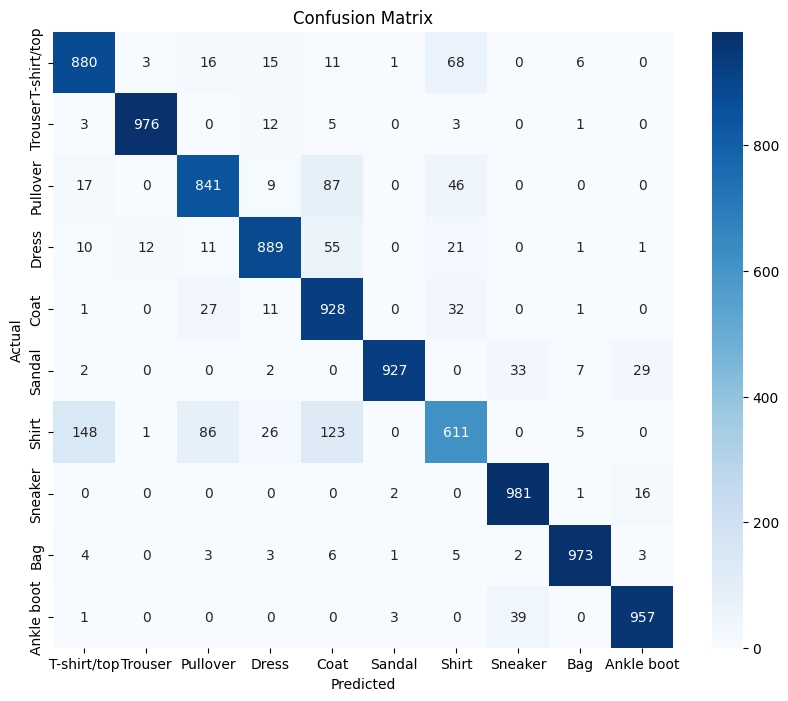

In [22]:
cm = confusion_matrix(test_labels, Y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

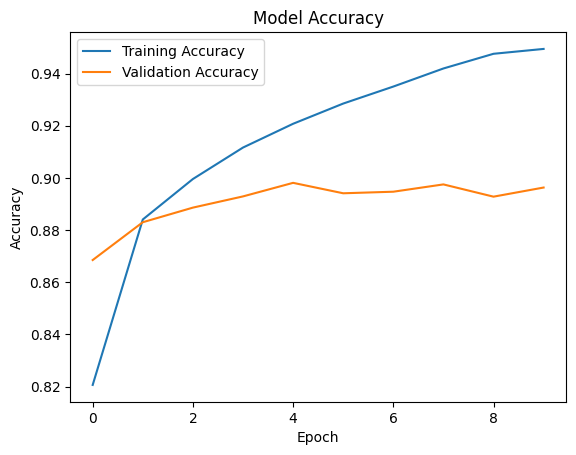

In [29]:
# Plot the training and validation accuracy values

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(loc="upper left")
plt.show()

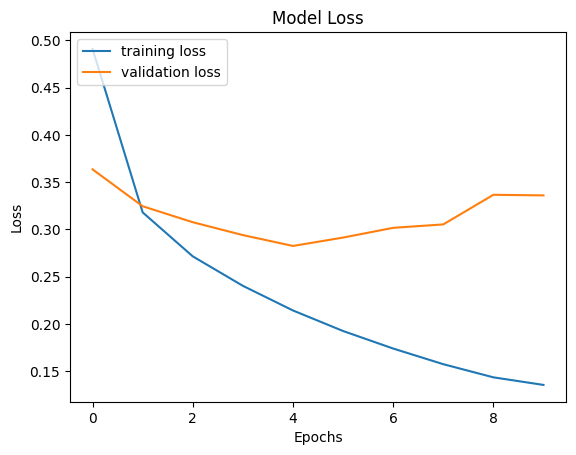

In [24]:
# plot the training and validation loss values

plt.plot(history.history["loss"],label = "training loss")
plt.plot(history.history["val_loss"],label = "validation loss")
plt.legend(loc = "upper left")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step


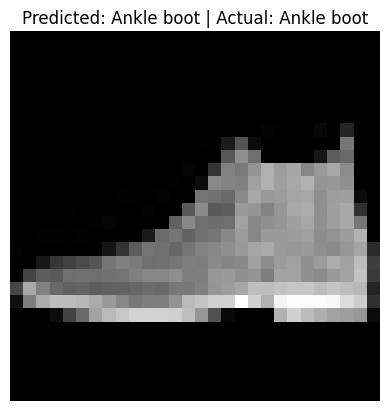

In [25]:
sample_index = 0

sample_image = test_images[sample_index]
prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_label = np.argmax(prediction)

plt.imshow(sample_image.reshape(28, 28), cmap="gray")
plt.title(
    f"Predicted: {class_names[predicted_label]} | Actual: {class_names[test_labels[sample_index]]}"
)
plt.axis("off")
plt.show()

In [26]:
model.save("fashion_mnist_cnn_model.keras")

## Conclusion

In this project, Fashion MNIST image classification was performed using a Convolutional Neural Network.

- The dataset contained 60,000 training images and 10,000 test images.
- Images were normalized and reshaped for CNN input.
- A CNN model was trained using TensorFlow/Keras.
- The model achieved approximately 90% test accuracy.
- Classification report and confusion matrix were used for detailed evaluation.
- The trained model was saved for future deployment.

This project demonstrates the use of CNNs for multi-class image classification.